## _Objective_
_Develop an inference pipeline that loads the trained Random Forest model, predicts the Health Index of new transformers using engineered features, explains predictions using SHAP, identifies likely root causes, and provides maintenance recommendations._

In [61]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import os
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the trained model
model = joblib.load("../Model/RandomForest_HealthIndex.pkl")
# Load the feature names
feature_names = joblib.load("../Model/model_features.pkl")
# load the Oil Scaler 
scaler = joblib.load("../Model/oil_scaler.pkl")

### _Validate User Input_
_Validate whether all required laboratory parameters are provided by the user._

In [4]:
def validate_input(transformer_data):
    
    required_features = [
        "Hydrogen",
        "Oxigen",
        "Nitrogen",
        "Methane",
        "CO",
        "CO2",
        "Ethylene",
        "Ethane",
        "Acethylene",
        "DBDS",
        "Power factor",
        "Interfacial V",
        "Dielectric rigidity",
        "Water content"
    ]

    missing = [
        feature
        for feature in required_features
        if feature not in transformer_data
    ]

    if missing:
        raise ValueError(
            f"Missing required features: {missing}"
        )

    return True

### _Feature Engineering_
_Convert raw laboratory measurements into model-ready engineered features._

In [16]:
def engineer_features(transformer_data):

    # Convert dictionary into DataFrame
    df = pd.DataFrame([transformer_data])

    # TDCG
    df["TDCG"] = (
        df["Hydrogen"]
        + df["Methane"]
        + df["Ethane"]
        + df["Ethylene"]
        + df["Acethylene"]
        + df["CO"]
    )

    # Thermal Stress Score
    df["Thermal_Stress_Score"] = (
        df["Methane"] +
        df["Ethylene"] +
        df["Ethane"]
    )

    # Water / BDV Ratio
    epsilon = 1e-6
    df["Water_BDV_Ratio"] = (
        df["Water content"]
        / (df["Dielectric rigidity"] + epsilon)  
    )

    # Oil Degradation Score
    oil_features = [
        "Water content",
        "Dielectric rigidity",
        "Interfacial V",
        "Power factor",
        "DBDS"
    ]
    
    oil_scaled = scaler.transform(df[oil_features])
    oil_scaled = pd.DataFrame(
        oil_scaled,
        columns=oil_features
    )

    df["Oil_degradation_score"] = (
        oil_scaled["Water content"]
        + oil_scaled["Power factor"]
        + oil_scaled["DBDS"]
        + (1 - oil_scaled["Interfacial V"])
        + (1 - oil_scaled["Dielectric rigidity"])
    ) / 5

    # Arrange Features
    df = df[feature_names]

    return df

### _Predict Health Index_
_Predict the Health Index using the trained Random Forest model._


In [6]:
def predict_health_index(model_input):

    health_index = model.predict(model_input)[0]

    return float(health_index)

### _Health Category_
_Classify the predicted Health Index into the corresponding Health Category._

In [7]:
def assign_health_category(health_index):

    if health_index > 89:
        return "Excellent"

    elif health_index > 69:
        return "Good"

    elif health_index > 49:
        return "Fair"

    else:
        return "Poor"

### _Explain Prediction using SHAP_


In [8]:
# Create SHAP explainer once
explainer = shap.TreeExplainer(model)

def explain_prediction(model_input, max_display=10):
    
    # Compute SHAP values
    shap_values = explainer(model_input)

    shap.plots.waterfall(
        shap_values[0],
        max_display=max_display
    )

    return shap_values[0]

### Root Cause Analysis


In [32]:
def root_cause_analysis(shap_result, top_n=5):

    # Create DataFrame
    root_cause_df = pd.DataFrame({

        "Feature": shap_result.feature_names,

        "Feature Value": shap_result.data,

        "SHAP Value": shap_result.values

    })

    # Absolute SHAP magnitude
    root_cause_df["Absolute Impact"] = (
        root_cause_df["SHAP Value"].abs()
    )

    # Engineering interpretation
    root_cause_df["Impact on Health Index"] = np.where(

        root_cause_df["SHAP Value"] >= 0,

        "Increased Health Index",

        "Decreased Health Index"

    )

    # Sort by importance
    root_cause_df = (
        root_cause_df
        .sort_values("Absolute Impact", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    # Rank
    root_cause_df.index += 1
    root_cause_df.index.name = "Rank"

    return root_cause_df

In [59]:
def identify_root_cause(category, root_cause_df):

    top_features = root_cause_df["Feature"].tolist()

    # Excellent
    if category == "Excellent":

        return (
            "No significant degradation detected."
        )

    # Poor
    if category == "Poor":

        if "TDCG" in top_features:

            return (
                "Severe thermal/electrical fault indicated by extremely high "
                "combustible gas generation (TDCG)."
            )

        elif "Oil_degradation_score" in top_features:

            return (
                "Severe oil degradation and insulation ageing detected. "
                "Oil quality has significantly deteriorated."
            )

        elif "Water_BDV_Ratio" in top_features:

            return (
                "Severe moisture contamination has reduced dielectric strength, "
                "increasing insulation failure risk."
            )

        elif "CO" in top_features or "CO2" in top_features:

            return (
                "Advanced cellulose insulation ageing indicated by elevated "
                "carbon oxide gases."
            )

        else:

            return (
                "Multiple degradation mechanisms detected. Immediate engineering "
            )

    # Fair
    elif category == "Fair":

        if "TDCG" in top_features:

            return (
                "Moderate thermal stress with increasing combustible gas generation."
            )

        elif "Oil_degradation_score" in top_features:

            return (
                "Progressive oil degradation and insulation ageing detected."
            )

        elif "Water_BDV_Ratio" in top_features:

            return (
                "Moisture contamination is beginning to affect dielectric performance."
            )

        elif "CO" in top_features or "CO2" in top_features:

            return (
                "Early paper insulation degradation indicated by carbon oxide gases."
            )

        else:

            return (
                "Moderate deterioration detected requiring preventive maintenance."
            )

    # Good
    elif category == "Good":

        if "Oil_degradation_score" in top_features:

            return (
                "Early signs of oil ageing detected."
            )

        elif "CO2" in top_features:

            return (
                "Minor insulation ageing detected."
            )

        elif "TDCG" in top_features:

            return (
                "Low-level combustible gas generation detected; continue monitoring."
            )

        else:

            return (
                "Minor degradation detected. Continue periodic monitoring."
            )

    # --------------------------------------------------

    return (
        "Engineering diagnosis unavailable."
    )

### _Maintenance Recommendation_

In [22]:
def maintenance_recommendation(category, root_cause_df):

    recommendations = []

    if category == "Excellent":

        recommendations.append(
            "Continue routine monitoring and periodic oil testing."
        )

    elif category == "Good":

        recommendations.append(
            "Increase DGA and oil testing frequency."
        )

    elif category == "Fair":

        recommendations.append(
            "Plan preventive maintenance and detailed inspection."
        )

    else:

        recommendations.append(
            "Immediate inspection and corrective maintenance are recommended."
        )

    return recommendations

### _Generate Diagnostic Report_


In [57]:
def generate_report(
    health_index,
    category,
    root_cause_df,
    diagnosis,
    recommendations
):

    print("=" * 70)
    print("           TRANSFORMER HEALTH ASSESSMENT REPORT")
    print("=" * 70)

    print(f"\nPredicted Health Index : {health_index:.2f}")
    print(f"Health Category        : {category}")
    print(f"Likely Root Cause   : {diagnosis}")

    print("\n" + "-" * 70)
    print("Top Root Causes")
    print("-" * 70)
    
    display(
        root_cause_df[
            [
                "Feature",
                "Feature Value",
                "SHAP Value",
                "Impact on Health Index"
            ]
        ]
    )

    print("\n" + "-" * 70)
    print("Maintenance Recommendations")
    print("-" * 70)

    for rec in recommendations:

        print(f"• {rec}")

    print("\n" + "=" * 70)
    print("End of Report")
    print("=" * 70)

### Transformer Health Diagnosis Pipeline

In [62]:
def diagnose_transformer(transformer_data):
    
    # Step 1 : Validate Input
    validate_input(transformer_data)

    # Step 2 : Feature Engineering
    model_input = engineer_features(transformer_data)

    # Step 3 : Predict Health Index
    health_index = predict_health_index(model_input)

    # Step 4 : Health Category
    category = assign_health_category(health_index)

    # Step 5 : SHAP Explanation
    shap_result = explain_prediction(model_input)

    # Step 6 : Root Cause Analysis
    root_causes = root_cause_analysis(shap_result)

    diagnosis = identify_root_cause(
    category,
    root_causes
    )

    # Step 7 : Maintenance Recommendation
    recommendations = maintenance_recommendation(
        category,
        root_causes
    )

    # Step 8 : Final Report
    generate_report(
        health_index,
        category,
        root_causes,
        diagnosis,
        recommendations
    )
    
    # Save Diagnosis History
    
    # Output folder
    output_dir = "../Output"
    os.makedirs(output_dir, exist_ok=True)

    # CSV file
    output_file = os.path.join(
        output_dir,
        "Transformer_Diagnosis_History.csv"
    )

    # Create Diagnosis ID
    if os.path.exists(output_file):
        history = pd.read_csv(output_file)
        diagnosis_id = f"D{len(history)+1:06d}"

    else:
        history = pd.DataFrame()
        diagnosis_id = "D00001"
        
    # Current Date & Time
    diagnosis_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Raw Input
    raw_input = transformer_data.copy()

    raw_df = pd.DataFrame([raw_input])

    # Engineered Features
    engineered_df = model_input.copy()

    # Remove duplicate columns
    engineered_df = engineered_df.drop(
        columns=raw_df.columns,
        errors="ignore"
    )

    # Combine Everything
    record = pd.concat(
        [
            raw_df.reset_index(drop=True),
            engineered_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Insert Metadata
    record.insert(
        0,
        "Diagnosis_ID",
        diagnosis_id
    )

    record.insert(
        1,
        "Diagnosis_Time",
        diagnosis_time
    )

    # Prediction Results
    record["Predicted_Health_Index"] = round(
        health_index,
        2
    )

    record["Health_Category"] = category

    record["Engineering_Diagnosis"] = diagnosis

    record["Maintenance_Recommendations"] = " | ".join(
        recommendations
    )

    # Append to Existing History
    if history.empty:

        history = record

    else:

        history = pd.concat(
            [
                history,
                record
            ],
            ignore_index=True
        )

    # Save CSV
    history.to_csv(
        output_file,
        index=False
    )

    print("=" * 60)
    print("Diagnosis saved successfully.")
    print(f"Diagnosis ID : {diagnosis_id}")
    print(f"Saved to     : {output_file}")
    print("=" * 60)
    
    # Return Results
    return {
        "Health Index": health_index,
        "Health Category": category,
        "Engineering Diagnosis": diagnosis,
        "Root Causes": root_causes,
        "Recommendations": recommendations
    }

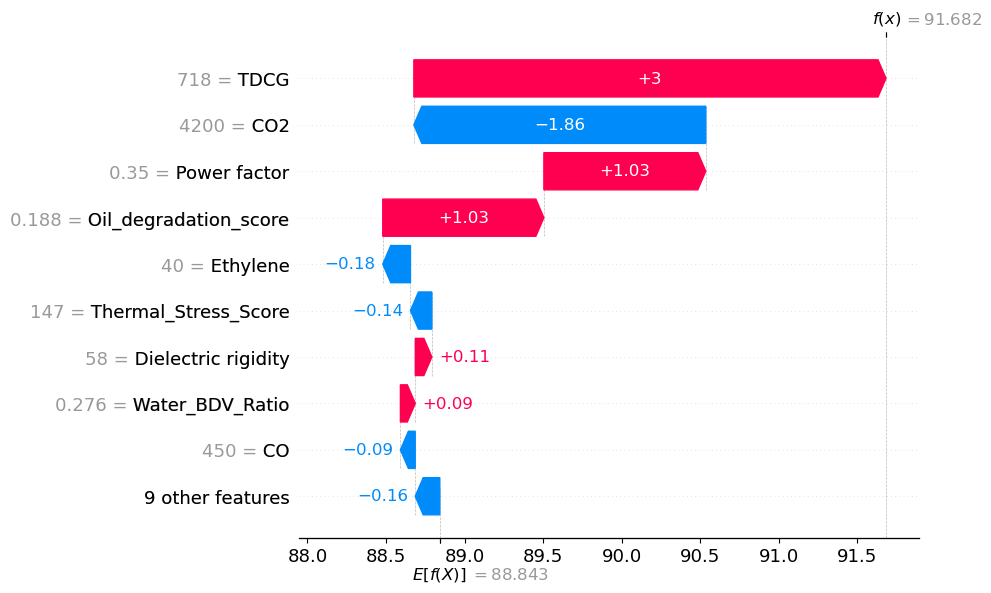

           TRANSFORMER HEALTH ASSESSMENT REPORT

Predicted Health Index : 91.68
Health Category        : Excellent
Likely Root Cause   : No significant degradation detected.

----------------------------------------------------------------------
Top Root Causes
----------------------------------------------------------------------


,Feature,Feature Value,SHAP Value,Impact on Health Index
Rank,,,,
1,TDCG,718.000000,3.004487,Increased Health Index
2,CO2,4200.000000,-1.857731,Decreased Health Index
3,Power factor,0.350000,1.030399,Increased Health Index
4,Oil_degradation_score,0.188332,1.025203,Increased Health Index
5,Ethylene,40.000000,-0.176183,Decreased Health Index



----------------------------------------------------------------------
Maintenance Recommendations
----------------------------------------------------------------------
• Continue routine monitoring and periodic oil testing.

End of Report
Diagnosis saved successfully.
Diagnosis ID : D00001
Saved to     : ../Output\Transformer_Diagnosis_History.csv


In [63]:
new_transformer = {

    "Hydrogen":120,
    "Oxigen":1800,
    "Nitrogen":62000,
    "Methane":85,
    "CO":450,
    "CO2":4200,
    "Ethylene":40,
    "Ethane":22,
    "Acethylene":1,
    "DBDS":18,
    "Power factor":0.35,
    "Interfacial V":42,
    "Dielectric rigidity":58,
    "Water content":16
}

results = diagnose_transformer(new_transformer)